<a href="https://colab.research.google.com/github/eliezermiranda/03/blob/main/02_PyTorch_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/diogoflim/iap/blob/main/02_PyTorch_intro.ipynb)

# UNIVERSIDADE FEDERAL FLUMINENSE

**TCE11616 - Introdução ao Aprendizado Profundo**

**Prof.: Diogo Ferreira de Lima Silva**

Nessa aula, implementaremos uma regressão linear com PyTorch.

**Ideia central da aula:** um modelo é uma *família* de equações

$$y = f[x, \phi]$$

Treinar é escolher o membro $\hat{\phi}$ que minimiza uma **função de perda** $\mathcal{L}[\phi]$ sobre os dados de treinamento.

## 0. Preparação do ambiente

Se estiver no Google Colab, o PyTorch já vem instalado. Localmente, use:

```bash
pip install torch matplotlib numpy
```

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())

SEED =42 # Fixando uma semente aleatória para garantir reproducibilidade
torch.manual_seed(SEED)

PyTorch: 2.11.0+cpu
GPU disponível: False


---
## 1. Tensores: o objeto básico do PyTorch

Um **tensor** é um array multidimensional, muito parecido com o `ndarray` do NumPy.

A diferença que importa para nós é que o tensor sabe **rastrear operações** para calcular derivadas automaticamente e pode viver na GPU.

In [2]:
# Criando tensores
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.zeros(2, 3)
c = torch.randn(2, 3)   # valores vindos de uma dist. normal padrão

print(f'a = {a}')
print(f'b = {b}')
print(f'c = {c}')

a = tensor([1., 2., 3.])
b = tensor([[0., 0., 0.],
        [0., 0., 0.]])
c = tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])


In [4]:
print(f'shape de a: {a.shape}')
print(f'shape de b: {b.shape}')

print(f'tipo de c: {c.dtype}')

shape de a: torch.Size([3])
shape de b: torch.Size([2, 3])
tipo de c: torch.float32


#### Operações são vetorizadas, como no NumPy


In [5]:
x = torch.tensor([1.0, 2.0, 3.0, 4.0])

print("x * 2      =", x * 2)
print("x ** 2     =", x ** 2)
print("soma       =", x.sum())
print("média      =", x.mean())

x * 2      = tensor([2., 4., 6., 8.])
x ** 2     = tensor([ 1.,  4.,  9., 16.])
soma       = tensor(10.)
média      = tensor(2.5000)


#### Ida e volta com NumPy


In [6]:
arr = np.array([10.0, 20.0, 30.0])
t = torch.from_numpy(arr)          # NumPy -> tensor
de_volta = t.numpy()               # tensor -> NumPy

print(t, type(t))
print(de_volta, type(de_volta))

tensor([10., 20., 30.], dtype=torch.float64) <class 'torch.Tensor'>
[10. 20. 30.] <class 'numpy.ndarray'>


### Atenção ao `shape`

Boa parte dos erros iniciais em PyTorch vem de dimensões incompatíveis.

Uma convenção que usaremos sempre: a **primeira dimensão é o número de exemplos**.

Ou seja, um conjunto com 80 exemplos e 1 feature deve ter shape `(80, 1)`.

Assim, devemos transformar os "vetores unidimensionais" usando o método .reshape(-1,1).

In [ ]:
v = torch.randn(80)              # vetor: shape (80,)
m = v.reshape(-1, 1)             # matriz coluna: shape (80, 1)

print("v.shape =", v.shape)
print("m.shape =", m.shape)

v.shape = torch.Size([80])
m.shape = torch.Size([80, 1])


In [ ]:
print(f'v = {v}')
print("-----------")
print(f'm = {m}')

v = tensor([-0.2483, -1.2082, -0.4777,  0.5201,  1.6423, -0.1596, -0.4974,  0.4396,
         2.0024,  0.4664,  1.5730, -0.9228,  1.2791,  1.2964,  0.6105,  1.3347,
        -1.1109,  0.0915, -2.3169, -0.2168, -1.3847, -0.8712, -0.2234,  1.7174,
        -0.5920, -0.0631, -0.8286,  0.3309, -1.5576,  0.9956, -0.8798, -0.6011,
         1.3123,  0.6872, -1.0892, -0.3553, -0.9138, -0.6581,  0.0780,  0.5258,
         1.1790, -0.4345, -1.3864, -1.2862, -1.4032,  0.0360, -0.0635,  0.6756,
         0.3672,  0.1754,  1.3852, -0.4459,  1.4451,  0.8564,  2.2181,  0.5232,
         1.1754,  0.5612, -0.4527, -0.7718, -0.1722,  0.5238,  0.0566,  0.4263,
         0.1971, -1.1441,  0.3383,  1.6992,  0.0109, -0.3387, -1.3407, -0.5854,
        -0.5644,  1.0563, -1.4692,  1.4332,  0.7440, -0.4816, -1.0495,  0.6039])
-----------
m = tensor([[-0.2483],
        [-1.2082],
        [-0.4777],
        [ 0.5201],
        [ 1.6423],
        [-0.1596],
        [-0.4974],
        [ 0.4396],
        [ 2.0024],
        

---
## 2. Gerando um conjunto aleatório de dados

Vamos gerar 100 exemplos a partir de uma relação linear com ruído gaussiano:

$$ y = 1,5 + 0,8\,x + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, 1)$$

Note que conhecemos a resposta verdadeira ($\phi_0 = 1,5$ e $\phi_1 = 0,8$) sobre o processo gerador dos dados porque **nós** o criamos. Isso é um luxo que não existe em problemas reais, mas é ótimo para verificar se nosso treinamento funciona.

In [ ]:
rng = np.random.default_rng(SEED) # rgn um gerador de números aleatórios com semente aleatória travada

N = 100
x_np = rng.uniform(0, 10, N)
y_np = 1.5 + 0.8 * x_np + rng.normal(0, 1.0, N)

# Separação treino/teste ANTES de qualquer ajuste
idx = rng.permutation(N)
idx_treino, idx_teste = idx[:80], idx[80:]

x_treino, y_treino = x_np[idx_treino], y_np[idx_treino]
x_teste,  y_teste  = x_np[idx_teste],  y_np[idx_teste]

print(f"Treino: {len(x_treino)} exemplos")
print(f"Teste:  {len(x_teste)} exemplos")

Treino: 80 exemplos
Teste:  20 exemplos


### Por que separar antes?

Se olharmos os dados de teste para tomar qualquer decisão de modelagem, eles deixam de ser uma estimativa honesta de generalização.

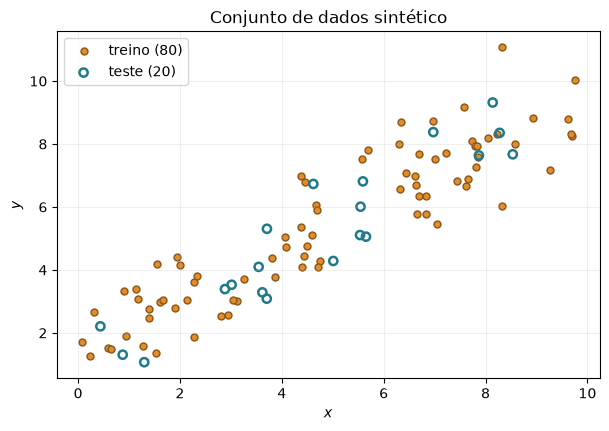

In [ ]:
plt.figure(figsize=(7, 4.5))
plt.scatter(x_treino, y_treino, c="#E08D2B", s=25, edgecolors="#8a5518", label="treino (80)")
plt.scatter(x_teste, y_teste, facecolors="none", s=35, edgecolors="#1F7A8C", linewidths=1.8, label="teste (20)")
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.title("Conjunto de dados sintético")
plt.legend(); plt.grid(alpha=0.2)
plt.show()

#### Convertendo para tensores

O PyTorch trabalha por padrão em `float32`, enquanto o NumPy usa `float64`.

Converter explicitamente evita erros de tipo mais adiante.

In [ ]:
X_treino = torch.tensor(x_treino, dtype=torch.float32).reshape(-1, 1)
Y_treino = torch.tensor(y_treino, dtype=torch.float32).reshape(-1, 1)
X_teste  = torch.tensor(x_teste,  dtype=torch.float32).reshape(-1, 1)
Y_teste  = torch.tensor(y_teste,  dtype=torch.float32).reshape(-1, 1)

print("X_treino:", X_treino.shape, "| Y_treino:", Y_treino.shape)

X_treino: torch.Size([80, 1]) | Y_treino: torch.Size([80, 1])


---
## 3. A função de perda, calculada à mão

Antes de treinar qualquer coisa, vamos **avaliar** as três retas da tabela dos slides.
A perda de mínimos quadrados é

$$ \mathcal{L}[\phi] = \sum_{i=1}^{I} \big(\phi_0 + \phi_1 x_i - y_i\big)^2 $$

In [ ]:
def modelo(X, phi0, phi1):
    return phi0 + phi1 * X


def perda_soma(X, Y, phi0, phi1):
    """SOMA dos quadrados dos desvios)."""
    residuos = modelo(X, phi0, phi1) - Y
    return (residuos ** 2).sum()


def perda_media(X, Y, phi0, phi1):
    """ (MSE) Erro quadrado médio."""
    residuos = modelo(X, phi0, phi1) - Y
    return (residuos ** 2).mean()

**Vejamos a performance para três retas candidatas:**

In [ ]:
candidatas = [
    ("(a) inclinação baixa demais", 4.50, 0.30),
    ("(b) inclinação alta demais",  0.20, 1.15),
    ("(c) mínimos quadrados",       1.59, 0.79),
]

In [ ]:
print(f"{'Reta':<30} {'phi0':>6} {'phi1':>6} {'L treino':>10} {'L/I tr':>8} {'L/I te':>8}")
print("-" * 72)

for nome, p0, p1 in candidatas:
    Ltr  = perda_soma(X_treino, Y_treino, p0, p1).item()
    mtr  = perda_media(X_treino, Y_treino, p0, p1).item()
    mte  = perda_media(X_teste,  Y_teste,  p0, p1).item()
    print(f"{nome:<30} {p0:>6.2f} {p1:>6.2f} {Ltr:>10.1f} {mtr:>8.2f} {mte:>8.2f}")

Reta                             phi0   phi1   L treino   L/I tr   L/I te
------------------------------------------------------------------------
(a) inclinação baixa demais      4.50   0.30      248.7     3.11     3.60
(b) inclinação alta demais       0.20   1.15      174.2     2.18     1.30
(c) mínimos quadrados            1.59   0.79       78.4     0.98     0.90


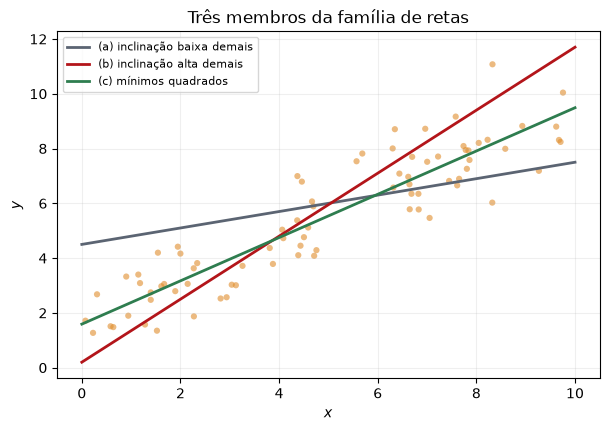

In [ ]:
grade_x = torch.linspace(0, 10, 100).reshape(-1, 1)

plt.figure(figsize=(7, 4.5))
plt.scatter(x_treino, y_treino, c="#E08D2B", s=20, alpha=0.6, edgecolors="none")
cores = ["#5B6472", "#B3151A", "#2E7D4F"]
for (nome, p0, p1), cor in zip(candidatas, cores):
    plt.plot(grade_x, modelo(grade_x, p0, p1), color=cor, lw=2, label=nome)
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.title("Três membros da família de retas")
plt.legend(fontsize=8); plt.grid(alpha=0.2)
plt.show()

---
## 4. `autograd`: o PyTorch calcula as derivadas por você

Ainda não estudamos como o treinamento ocorre de fato. No momento, pense como um processo como "descer a superfície" da função perda com uso da informação do gradiente.

Para isso precisamos do **gradiente**: as derivadas parciais

$$\partial \mathcal{L} / \partial \phi_0 \ \qquad \text{e} \qquad \partial \mathcal{L} / \partial \phi_1$$

Calcular derivadas à mão é viável para uma reta com 2 parâmetros. Para uma rede com milhões de parâmetros, não é. É por isso que o PyTorch existe.

Marcamos um tensor com `requires_grad=True` e ele passa a **registrar** todas as operações.

Ao chamar `.backward()`, o PyTorch percorre esse registro de trás para frente e preenche o campo `.grad`.

Para ilustrar o mecanismo, vejamos uma função muito simples:

$$ z = wˆ{2} + 5w \qquad =>  \qquad dz/dw = 2w + 5$$

In [ ]:
# Exemplo ilustrativo do mecanismo

w = torch.tensor(3.0, requires_grad=True)
z = w ** 2 + 5 * w
z.backward()

print("z      =", z.item())
print('-------')
print("dz/dw  =", w.grad.item(), "   (esperado: 2*3 + 5 = 11)")

z      = 24.0
-------
dz/dw  = 11.0    (esperado: 2*3 + 5 = 11)


---
## 5. Usando `nn.Module` e um otimizador

O código acima funciona, mas não escala: imagine escrever `phi.grad.zero_()` para
cada um dos milhões de parâmetros de uma rede.

O PyTorch oferece duas abstrações que resolvem isso:

- **`nn.Linear`** — encapsula os parâmetros (aqui, `weight` = $\phi_1$ e `bias` = $\phi_0$)
- **`torch.optim`** — encapsula a regra de atualização

Este é o padrão que usaremos no resto do curso.

In [ ]:
import torch.nn as nn


In [ ]:
# criando o nosos primeiro modelo com nn

torch.manual_seed(SEED)
modelo_nn = nn.Linear(in_features=1, out_features=1) # 1 entrada -> 1 saída

print("Parâmetros do modelo:")
for nome, p in modelo_nn.named_parameters():
    print(f"  {nome:<8} shape={tuple(p.shape)}  valor inicial={p.item():.3f}")

Parâmetros do modelo:
  weight   shape=(1, 1)  valor inicial=0.765
  bias     shape=(1,)  valor inicial=0.830


In [ ]:
torch.manual_seed(SEED)
modelo_nn = nn.Linear(in_features=1, out_features=1)
criterio = nn.MSELoss() # erro médio quadrático (MSE)
otimizador = torch.optim.SGD(modelo_nn.parameters(), lr=0.01)
n_epocas = 2000


hist_treino, hist_teste = [], []
for epoca in range(n_epocas):
    # ---------- treinamento
    modelo_nn.train()               # ativa o modo treinamento
    pred = modelo_nn(X_treino)      # passo forward na rede
    L = criterio(pred, Y_treino)    # calcula o custo
    otimizador.zero_grad()          # zera os gradientes de todos os parâmetros
    L.backward()                    # calcula os gradientes
    otimizador.step()               # dá um passo, atualizando os parâmetros

    # ---------- avaliação no conjunto de teste
    modelo_nn.eval()    # ativa o modo avaliação
    with torch.no_grad():   # desliga o cálculo de gradientes
        L_teste = criterio(modelo_nn(X_teste), Y_teste)  #calcula o custo no conjunto de teste

    hist_treino.append(L.item())
    hist_teste.append(L_teste.item())

    if epoca % 400 == 0:
        print(f"época {epoca:>5} | treino = {L.item():.4f} | teste = {L_teste.item():.4f}")

phi1_final = modelo_nn.weight.item()
phi0_final = modelo_nn.bias.item()
print(f"\nphi0 = {phi0_final:.3f}   (verdade: 1.500)")
print(f"phi1 = {phi1_final:.3f}   (verdade: 0.800)")

época     0 | treino = 1.7344 | teste = 0.8402
época   400 | treino = 0.9829 | teste = 0.8645
época   800 | treino = 0.9801 | teste = 0.8941
época  1200 | treino = 0.9801 | teste = 0.8987
época  1600 | treino = 0.9801 | teste = 0.8994

phi0 = 1.595   (verdade: 1.500)
phi1 = 0.785   (verdade: 0.800)


**A armadilha do `zero_()`**

O PyTorch **acumula** gradientes em vez de sobrescrevê-los. Se você esquecer de zerar, o gradiente da iteração 2 será a soma das iterações 1 e 2, e o treinamento diverge. Esse é provavelmente o erro mais comum de quem está começando.

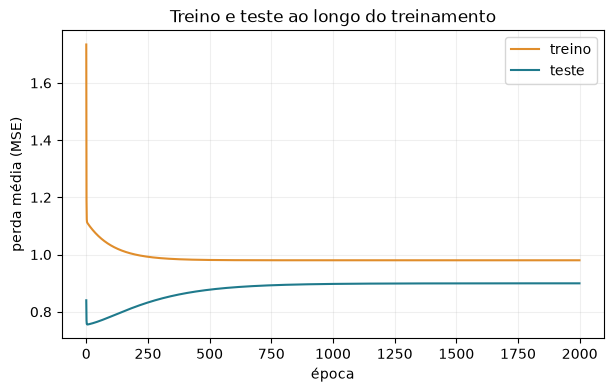

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(hist_treino, color="#E08D2B", lw=1.5, label="treino")
plt.plot(hist_teste,  color="#1F7A8C", lw=1.5, label="teste")
plt.xlabel("época"); plt.ylabel("perda média (MSE)")
plt.title("Treino e teste ao longo do treinamento")
#plt.xscale("log")
plt.legend(); plt.grid(alpha=0.2)
plt.show()

O comportamento do gráfico acima não é o esperado em ML. Normalmente, a curva da perda do conjunto de treinamento fica abaixo da curva do conjunto de teste. Você perceberá isso ao longo do semestre!

Como o conjunto de dados é pequeno e controlado, esse comportamento pode ocorrer por acaso. Não é um erro de código ou algo nesse sentido. Em um cenário como o apresentado neste notebook, o conjunto de teste pode dar "sorte".

Altere a seed e faça alguns testes!

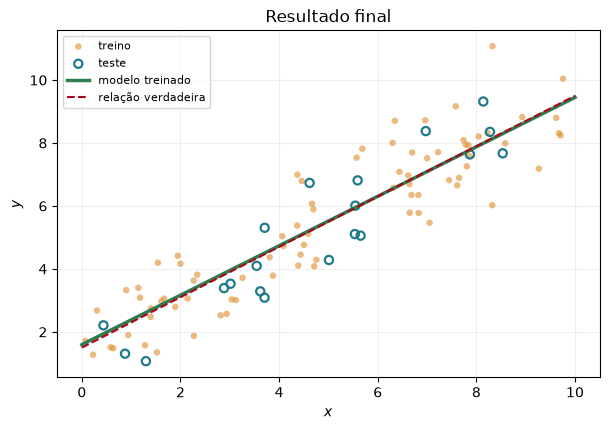

In [ ]:
with torch.no_grad():
    y_grade = modelo_nn(grade_x)

plt.figure(figsize=(7, 4.5))
plt.scatter(x_treino, y_treino, c="#E08D2B", s=22, alpha=0.6, edgecolors="none", label="treino")
plt.scatter(x_teste, y_teste, facecolors="none", s=35, edgecolors="#1F7A8C", linewidths=1.6, label="teste")
plt.plot(grade_x, y_grade, color="#2E7D4F", lw=2.5, label="modelo treinado")
plt.plot(grade_x, 1.5 + 0.8 * grade_x, "--", color="#AE0418", lw=1.5,label="relação verdadeira")
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.title("Resultado final")
plt.legend(fontsize=8); plt.grid(alpha=0.2)
plt.show()

---
## 6. Extrapolação

Vamos ver o que acontece quando pedimos ao modelo uma predição bem longe dos dados de treinamento.

In [ ]:
x_novos = torch.tensor([[5.0], [50.0], [500.0]])

with torch.no_grad():
    preds = modelo_nn(x_novos)

for xv, pv in zip(x_novos.flatten(), preds.flatten()):
    situacao = "interpolação" if 0 <= xv <= 10 else "EXTRAPOLAÇÃO"
    print(f"x = {xv:>7.1f}  ->  y = {pv:>8.2f}   ({situacao})")

x =     5.0  ->  y =     5.52   (interpolação)
x =    50.0  ->  y =    40.86   (EXTRAPOLAÇÃO)
x =   500.0  ->  y =   394.28   (EXTRAPOLAÇÃO)


Repare que o modelo **responde normalmente** nos três casos. Nenhum aviso, nenhum erro. Retorna normalmente apenas um número (rótulo previsto).

Para $x = 500$ a predição é uma extrapolação de cinquenta vezes o alcance dos dados sustentada unicamente pela suposição de que a relação continua linear para sempre.

**Nada nos dados justifica essa suposição.**

**Em produção, o modelo não sabe que está extrapolando**. Cabe a quem projeta o sistema monitorar se as entradas continuam vindo da mesma distribuição dos dados de treinamento.

---
## 7. E se tivermos mais de uma feature?

Até aqui, cada exemplo era descrito por **um único** número $x$. Na prática, quase nunca é assim: um imóvel tem área, número de quartos, idade, distância do centro...

A boa notícia é que **quase nada muda** em termos de programação. A família de equações passa a ser:

$$
y = f[\mathbf{x}, \boldsymbol{\phi}] = \phi_0 + \phi_1 x_1 + \phi_2 x_2 + \phi_3 x_3 + \phi_4 x_4 + \phi_5 x_5
$$

ou, em notação matricial, com $\mathbf{X}$ de shape $(I, D)$ contendo $I$ exemplos e $D$ features:

$$ \hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\phi} + \phi_0 $$

Continuamos com uma **família de funções**, uma **função de perda** (MSE) e um **otimizador**.

O que muda é apenas o **número de parâmetros**: de 2 para 6.

#### Gerando os dados

Vamos gerar 500 exemplos com 5 features

$$ y = 1{,}5 + 0{,}8\,x_1 - 1{,}5\,x_2 + 2{,}0\,x_3 + 0{,}3\,x_4 + 0{,}5\,x_5 + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, 1) $$


In [ ]:
rng5 = np.random.default_rng(SEED)

N5, D = 500, 5                             # 500 exemplos, 5 features
X_np = rng5.normal(0, 1, size=(N5, D))     # matriz de features: shape (500, 5)

phi0_verd = 1.5
phi_verd  = np.array([0.8, -1.5, 2.0, 0.3, 0.5])
y5_np = phi0_verd + X_np @ phi_verd + rng5.normal(0, 1.0, N5)   # @ é o produto matricial

In [ ]:
X_np[0:5]

array([[ 0.30471708, -1.03998411,  0.7504512 ,  0.94056472, -1.95103519],
       [-1.30217951,  0.1278404 , -0.31624259, -0.01680116, -0.85304393],
       [ 0.87939797,  0.77779194,  0.0660307 ,  1.12724121,  0.46750934],
       [-0.85929246,  0.36875078, -0.9588826 ,  0.8784503 , -0.04992591],
       [-0.18486236, -0.68092954,  1.22254134, -0.15452948, -0.42832782]])

In [ ]:
# Separação treino/teste

idx5 = rng5.permutation(N5)
idx5_treino, idx5_teste = idx5[:400], idx5[400:]

X5_treino_np, y5_treino_np = X_np[idx5_treino], y5_np[idx5_treino]
X5_teste_np,  y5_teste_np  = X_np[idx5_teste],  y5_np[idx5_teste]

print("X de treino:", X5_treino_np.shape, "| y de treino:", y5_treino_np.shape)
print("X de teste: ", X5_teste_np.shape,  "| y de teste: ", y5_teste_np.shape)

X de treino: (400, 5) | y de treino: (400,)
X de teste:  (100, 5) | y de teste:  (100,)


### Convertendo para tensores

Aqui aparece uma sutileza. Lembre da convenção: a primeira dimensão é o número de exemplos. Dessa vez, não precisamos para a matriz de features, pois ela já está o formato correto.

- `X` já nasce com shape `(400, 5)` — **não precisa** de `reshape`, pois as 5 colunas são exatamente as 5 features;
- `y` continua sendo um vetor `(400,)` e ainda precisa virar `(400, 1)`, porque a saída do modelo tem shape `(400, 1)`.

In [ ]:
X5_treino = torch.tensor(X5_treino_np, dtype=torch.float32)
Y5_treino = torch.tensor(y5_treino_np, dtype=torch.float32).reshape(-1, 1)
X5_teste  = torch.tensor(X5_teste_np,  dtype=torch.float32)
Y5_teste  = torch.tensor(y5_teste_np,  dtype=torch.float32).reshape(-1, 1)

print("X5_treino:", X5_treino.shape, "| Y5_treino:", Y5_treino.shape)
print("X5_teste: ", X5_teste.shape,  "| Y5_teste: ", Y5_teste.shape)

X5_treino: torch.Size([400, 5]) | Y5_treino: torch.Size([400, 1])
X5_teste:  torch.Size([100, 5]) | Y5_teste:  torch.Size([100, 1])


#### O modelo: uma única palavra muda

Antes tínhamos `nn.Linear(in_features=1, out_features=1)`. Agora, `in_features=5`.

O `weight` deixa de ser um número e passa a ser uma matriz de shape `(1, 5)`; o `bias` continua sendo um único número ($\phi_0$).

In [ ]:
torch.manual_seed(SEED)
modelo5 = nn.Linear(in_features=5, out_features=1)   # 5 entradas -> 1 saída

print("Parâmetros do modelo:")
for nome, p in modelo5.named_parameters():
    print(f"  {nome:<8} shape={tuple(p.shape)}  ({p.numel()} parâmetro(s))")

Parâmetros do modelo:
  weight   shape=(1, 5)  (5 parâmetro(s))
  bias     shape=(1,)  (1 parâmetro(s))


### O treinamento: exatamente o mesmo laço

Compare com o laço da Seção 5. Trocando os nomes das variáveis, é **linha por linha idêntico**.

Essa é a mensagem central: o PyTorch não precisa saber quantos parâmetros o modelo tem. O `autograd` percorre o grafo e o otimizador atualiza tudo que estiver em `modelo5.parameters()`.

In [ ]:
torch.manual_seed(SEED)
modelo5 = nn.Linear(in_features=5, out_features=1)
criterio5 = nn.MSELoss()
otimizador5 = torch.optim.SGD(modelo5.parameters(), lr=0.01)
n_epocas = 2000

hist5_treino, hist5_teste = [], []
for epoca in range(n_epocas):
    # ---------- treinamento
    modelo5.train()
    pred = modelo5(X5_treino)
    L = criterio5(pred, Y5_treino)
    otimizador5.zero_grad()
    L.backward()
    otimizador5.step()

    # ---------- avaliação no conjunto de teste
    modelo5.eval()
    with torch.no_grad():
        L_teste = criterio5(modelo5(X5_teste), Y5_teste)

    hist5_treino.append(L.item())
    hist5_teste.append(L_teste.item())

    if epoca % 500 == 0:
        print(f"época {epoca:>5} | treino = {L.item():.4f} | teste = {L_teste.item():.4f}")

print(f"\nperda final -> treino = {hist5_treino[-1]:.4f} | teste = {hist5_teste[-1]:.4f}")

época     0 | treino = 11.1147 | teste = 9.2792
época   500 | treino = 1.0074 | teste = 1.0428
época  1000 | treino = 1.0074 | teste = 1.0428
época  1500 | treino = 1.0074 | teste = 1.0428

perda final -> treino = 1.0074 | teste = 1.0428


#### Parâmetros aprendidos

In [ ]:
pesos = modelo5.weight.detach().flatten().numpy()   # shape (5,)
vies  = modelo5.bias.item()

print(f'w = {pesos}')
print(f'b = {vies}')

w = [ 0.8756946 -1.4705452  1.9695942  0.257632   0.5667563]
b = 1.5666917562484741


### Alguns comentários

O exemplo acima foi construído para ser fácil: as 5 features vieram todas de uma $\mathcal{N}(0, 1)$, ou seja, já estavam **na mesma escala**. Em problemas reais isso raramente acontece.

**1. Normalização das features.** Imagine prever o preço de um imóvel com `área` (em torno de 100 m²) e `nº de quartos` (em torno de 3). O gradiente em relação ao peso da área fica ~30 vezes maior que o do número de quartos. Uma taxa de aprendizado "boa" para a feature pequena pode ser ruim para a feature grande. O remédio padrão é **padronizar** cada coluna:

$$ x_j^{\text{norm}} = \frac{x_j - \mu_j}{\sigma_j} $$

```python
media = X5_treino.mean(dim=0)     # média por coluna (feature)
desvio = X5_treino.std(dim=0)

X5_treino_norm = (X5_treino - media) / desvio
X5_teste_norm  = (X5_teste  - media) / desvio   
```

Repare no detalhe crucial: $\mu$ e $\sigma$ são calculados **apenas no conjunto de treinamento** e depois aplicados ao teste.

Calcular a média sobre o conjunto completo é uma forma sutil de vazamento (*data leakage*). Os dados de teste teriam influenciado a transformação e deixariam de ser uma estimativa honesta de generalização.


**2. Usamos o conjunto de treinamento inteiro a cada época.** Nosso laço calcula o gradiente sobre os 400 exemplos de uma vez (*full-batch*). Veremos também o **gradiente descendente estocástico com mini-lotes**, em que cada passo usa apenas uma amostra dos dados.

---
## Para praticar

**1.** Altere a taxa de aprendizado para `lr = 0.001` e depois para `lr = 0.05`. O que acontece em cada caso? Quantas épocas são necessárias para convergir?

**2.** Aumente o ruído na geração dos dados de $\sigma = 1$ para $\sigma = 4$. Os parâmetros estimados ainda se aproximam de $(1{,}5;\ 0{,}8)$? E a perda final?

---
